### Build Changepoint detection model on TAQ Trades with adaptive penalties 

In [19]:
! pip install ruptures

  Using cached ruptures-1.1.7-cp38-cp38-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (1.1 MB)


In [20]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import sys
import ruptures as rpt

sys.path.append('/home/jovyan/personal/TAQ-Query-Scripts/data')
sys.path.append('/home/jovyan/personal/Changepoint_LOB/Lasso/CPD')
from adaptive_tf import l1tf_adaptive

### TAQ Data AAPL

Snippet of AAPL trades on NYSE for 1 hour

In [158]:
trades=pd.read_csv('/home/jovyan/personal/TAQ-Query-Scripts/data/AAPL_trades.csv')
trades
trades.index=pd.to_datetime(trades['Time'],format="%Y-%m-%d %H:%M:%S.%f")
trades=trades[trades.index < datetime.strptime(f"2020-01-06 16:00:00", "%Y-%m-%d %H:%M:%S")]
trades=trades[trades.index > datetime.strptime(f"2020-01-06 9:30:00", "%Y-%m-%d %H:%M:%S")]

Text(0.5, 1.0, 'APPL Trade Price 01/06/2020')

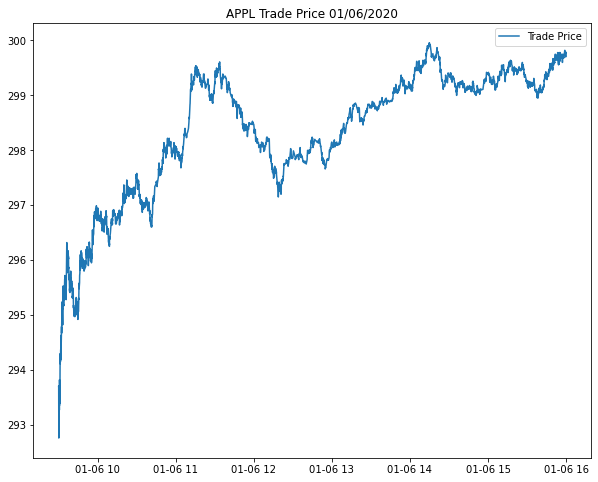

In [160]:
fig,ax=plt.subplots(figsize=(10,8))
ax.plot(trades['Trade_Price'],label='Trade Price')
ax.legend()
ax.set_title("APPL Trade Price 01/06/2020")

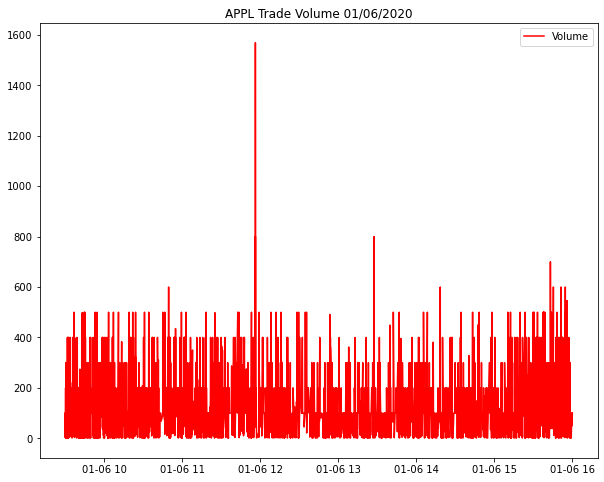

In [162]:
fig,ax=plt.subplots(figsize=(10,8))
ax.set_title("APPL Trade Volume 01/06/2020")
ax.plot(trades['Trade_Volume'],color='red',label='Volume')
ax.legend()

### Apply Kernel Smoothing on Volume Time Series

Utilize the Epanechnikov Kernel $K(u)=0.75(1-u^2)$

In [163]:
def compute_kernel(x_0,x_i,bandwidth):
    '''
    Kernel Smooth Time Series up to time T
    '''
    scale=abs((x_0-x_i).total_seconds()/bandwidth) # absolute distance in time
    
    if scale <1:
    
        weight= 0.75*((1-scale)**2)
    else:
        weight=0
   
    return weight

def kernel_smooth(x0,series,bandwidth):
    '''
    x0: index of recent observation
    series: observations
    '''
    num=0
    ker=0
    
    for index,val in series.items():
        
        kernel=compute_kernel(x0,index,bandwidth) # compute weight as a function of time 
        ker+=kernel
        num+=kernel*val
        
    return num/ker

def smooth_series(series,bandwidth):
    smooth=[]
    for x_i_index, x_i in series.items():
        smoothed_val=kernel_smooth(x_i_index,series,bandwidth)
        smooth.append(smoothed_val)
    return pd.Series(smooth,index=series.index)

def cross_validate_bandwidth(series):
    
    ## grid search across bandwidth params
    
    # leave out validation set 
    
    # return optimal bandwidth poaram 
    
    pass

In [164]:
vol=trades['Trade_Volume']

smoothed=smooth_series(vol,100)

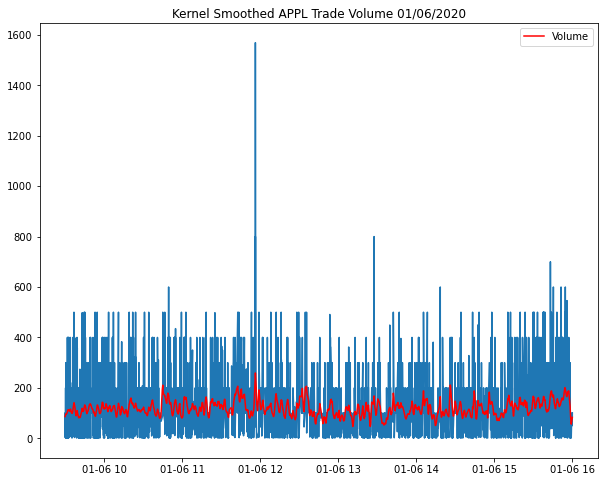

In [180]:
fig,ax=plt.subplots(figsize=(10,8))
ax.set_title("Kernel Smoothed APPL Trade Volume 01/06/2020")
ax.plot(vol)
ax.plot(smoothed,color='red',label='Volume')
ax.legend()

### Changepoint Detection with Adaptive Penalty Strength for Exogenous Information
- The idea here is to apply a time dependent penalty method where strength is determined via a independent series 
- Here the naive choice is to use the original volume series as penalty

In [168]:
pen=smoothed.values[1:-1].reshape(-1,1)
y=trades['Trade_Price'].values.reshape(-1,1)
x_adapt,status,gap_adapt=l1tf_adaptive(y,lambda_p=pen)

solved


### Steps
- Alter code to allow for non-uniformly observed events
- Implement an adaptively changing penalty function 

Text(0.5, 1.0, 'Adaptive Trend Filtering APPL Trade Price 01/06/2020')

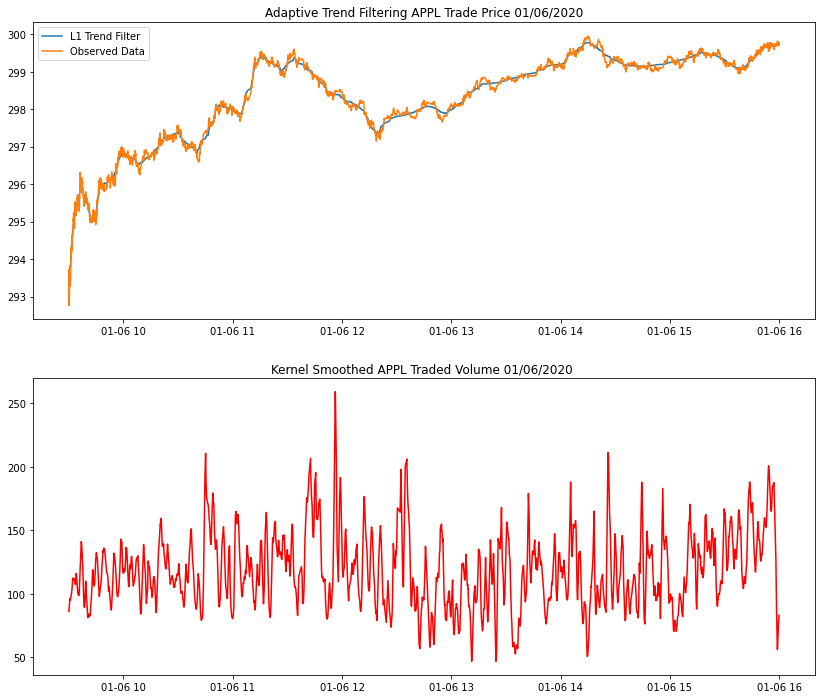

In [181]:
fig,ax=plt.subplots(2,1,figsize=(14,12))
ax[0].plot(trades.index,x_adapt,label= 'L1 Trend Filter')
ax[0].plot(trades.index,y, label='Observed Data')

ax[1].plot(smoothed,label='Volume',color='red')
ax[1].set_title('Kernel Smoothed APPL Traded Volume 01/06/2020 ')
ax[0].legend()
ax[0].set_title("Adaptive Trend Filtering APPL Trade Price 01/06/2020")

### Identify Changepoints within the L1 Trend Filter
Utilize Dynamic Programming Step within Levy-Leduc Paper

In [173]:
# change point detection
model = "l1"  # "l2", "rbf"
algo = rpt.Dynp(model=model, min_size=3, jump=5).fit(x_adapt)
my_bkps = np.array(algo.predict(n_bkps=8))-1


Text(0.5, 1.0, 'L1 Trend Filtering APPL Trade Price 01/06/2020')

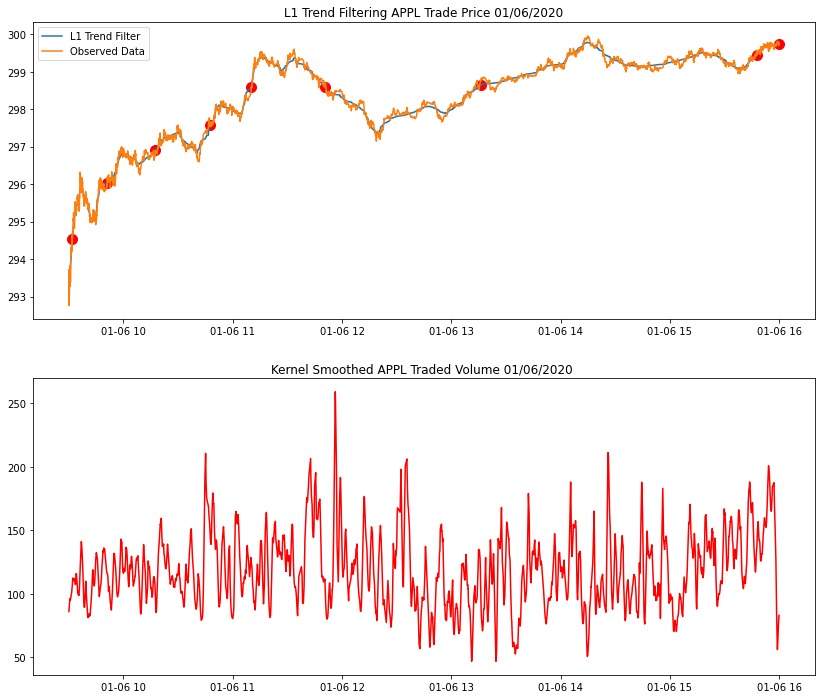

In [179]:
fig,ax=plt.subplots(2,1,figsize=(14,12))
ax[0].plot(trades.index,x_adapt,label= 'L1 Trend Filter')
ax[0].plot(trades.index,y, label='Observed Data')
ax[0].scatter(trades.index[my_bkps],x_adapt[my_bkps],color='red',s=100)

ax[1].plot(smoothed,label='Volume',color='red')
ax[1].set_title('Kernel Smoothed APPL Traded Volume 01/06/2020 ')
ax[0].legend()
ax[0].set_title("L1 Trend Filtering APPL Trade Price 01/06/2020")